# Simulação térmica didática com rampa de temperatura e animação

Esta versão adiciona duas coisas ao notebook anterior:

- **rampa de temperatura** de **1 K até 10000 K** ao longo da simulação;
- **animação da trajetória** molecular.

A dinâmica continua sendo uma **MD didática**: há massas, velocidades, forças, integração temporal e um termostato simples.  
A simulação **para automaticamente** quando uma ligação excede o critério geométrico de quebra:

$$
d_{ij} > f_{\mathrm{break}}\,(r_i^{\mathrm{cov}} + r_j^{\mathrm{cov}})
$$

> **Importante**  
> Isto ainda **não** é dinâmica reativa quantitativa. A quebra é detectada por critério geométrico, o que é adequado para fins didáticos.


``Instalar via requirements, ao invés de instala no notebook, para evitar conflito em ambientes diferentes``

In [38]:
#!pip install rdkit

In [39]:
import math
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from rdkit import Chem
from rdkit.Chem import AllChem, Draw


In [40]:
# =========================
# Escolha da molécula
# =========================
smiles = "CC(C)(O1)C[C@@H](O)[C@@]1(O2)[C@@H](C)[C@@H]3CC=C4[C@]3(C2)C(=O)C[C@H]5[C@H]4CC[C@@H](C6)[C@]5(C)Cc(n7)c6nc(C[C@@]89(C))c7C[C@@H]8CC[C@@H]%10[C@@H]9C[C@@H](O)[C@@]%11(C)C%10=C[C@H](O%12)[C@]%11(O)[C@H](C)[C@]%12(O%13)[C@H](O)C[C@@]%13(C)CO"   # benzeno (teste)

# Rampa térmica
temperature_start = 1.0      # K
temperature_end = 10000.0    # K

# Parâmetros numéricos da dinâmica
n_steps = 12000
dt = 2.5e-4                  # passo de tempo em unidades internas
thermostat_tau = 0.03        # acoplamento do termostato
break_factor = 1.5           # quebra se d_ij > break_factor * (r_cov_i + r_cov_j)
break_persistence = 20       # número de passos consecutivos para confirmar a quebra
save_every = 10              # salvar um frame da trajetória a cada N passos

# Dica:
# - Se quebrar cedo demais, aumente break_factor ou diminua dt.
# - Se não quebrar nunca, aumente n_steps, diminua break_factor ou aumente temperature_end.


In [41]:
# =========================
# Construção da molécula e utilidades
# =========================
def build_molecule(smiles: str, seed: int = 0xF00D):
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if mol is None:
        raise ValueError("SMILES inválido.")
    status = AllChem.EmbedMolecule(mol, randomSeed=seed)
    if status != 0:
        raise RuntimeError("Falha ao gerar geometria 3D com RDKit.")
    AllChem.UFFOptimizeMolecule(mol)
    return mol

def get_positions(mol):
    conf = mol.GetConformer()
    return np.array([
        [conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())
    ], dtype=float)

def set_positions(mol, pos):
    conf = mol.GetConformer()
    for i, p in enumerate(pos):
        conf.SetAtomPosition(i, p)

def build_topology(mol):
    conf = mol.GetConformer()
    pt = Chem.GetPeriodicTable()

    atoms = [mol.GetAtomWithIdx(i) for i in range(mol.GetNumAtoms())]
    masses = np.array([a.GetMass() for a in atoms], dtype=float)
    radii = np.array([pt.GetRcovalent(a.GetAtomicNum()) for a in atoms], dtype=float)
    symbols = [a.GetSymbol() for a in atoms]

    pos = np.array([
        [conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())
    ], dtype=float)

    bond_k_map = {
        Chem.rdchem.BondType.SINGLE:   300.0,
        Chem.rdchem.BondType.DOUBLE:   500.0,
        Chem.rdchem.BondType.TRIPLE:   700.0,
        Chem.rdchem.BondType.AROMATIC: 450.0,
    }

    bonds = []
    neighbors = {i: set() for i in range(mol.GetNumAtoms())}

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        r0 = np.linalg.norm(pos[j] - pos[i])
        k = bond_k_map.get(bond.GetBondType(), 300.0)
        bonds.append((i, j, r0, k))
        neighbors[i].add(j)
        neighbors[j].add(i)

    one_three = set()
    for center in range(mol.GetNumAtoms()):
        nbrs = sorted(neighbors[center])
        for a in range(len(nbrs)):
            for b in range(a + 1, len(nbrs)):
                one_three.add(tuple(sorted((nbrs[a], nbrs[b]))))

    return pos, masses, radii, symbols, bonds, neighbors, one_three

EPSILON_MAP = {
    "H": 0.02,
    "C": 0.08,
    "N": 0.10,
    "O": 0.12,
    "S": 0.15,
    "F": 0.10,
    "Cl": 0.15,
    "Br": 0.20,
    "I": 0.25,
}

ATOM_SIZE_MAP = {
    "H": 80,
    "C": 140,
    "N": 170,
    "O": 170,
    "F": 170,
    "S": 210,
    "Cl": 220,
    "Br": 240,
    "I": 260,
}

ATOM_COLOR_MAP = {
    "H": "lightgray",
    "C": "black",
    "N": "royalblue",
    "O": "crimson",
    "F": "limegreen",
    "S": "goldenrod",
    "Cl": "green",
    "Br": "brown",
    "I": "purple",
}

def lj_params(symbol_i, symbol_j, radius_i, radius_j):
    sigma = 0.85 * (radius_i + radius_j)
    epsilon = math.sqrt(EPSILON_MAP.get(symbol_i, 0.08) * EPSILON_MAP.get(symbol_j, 0.08))
    return sigma, epsilon

def initialize_velocities(masses, temperature, seed=123):
    rng = np.random.default_rng(seed)
    vel = rng.normal(size=(len(masses), 3)) * np.sqrt(0.05 * max(temperature, 1e-6) / masses)[:, None]
    vel -= np.average(vel, axis=0, weights=masses)
    return vel

def kinetic_temperature(vel, masses):
    kinetic = 0.5 * np.sum(masses[:, None] * vel * vel)
    dof = max(1, 3 * len(masses) - 3)
    temperature = 2.0 * kinetic / dof
    return temperature, kinetic

def target_temperature_ramp(step, n_steps, t0, t1):
    if n_steps <= 1:
        return t1
    return t0 + (t1 - t0) * step / (n_steps - 1)


In [42]:
# =========================
# Campo de força didático
# =========================
def forces_and_energy(pos, radii, symbols, bonds, one_three):
    n = len(pos)
    forces = np.zeros_like(pos)
    energy = 0.0

    bonded_pairs = {tuple(sorted((i, j))) for i, j, _, _ in bonds}

    # 1) Ligações harmônicas
    for i, j, r0, k in bonds:
        rij = pos[j] - pos[i]
        r = np.linalg.norm(rij) + 1e-12
        dr = r - r0

        fij = k * dr * rij / r
        forces[i] += fij
        forces[j] -= fij
        energy += 0.5 * k * dr * dr

    # 2) Repulsão não ligante tipo WCA (LJ truncado no mínimo)
    for i in range(n):
        for j in range(i + 1, n):
            pair = (i, j)
            if pair in bonded_pairs or pair in one_three:
                continue

            rij = pos[j] - pos[i]
            r = np.linalg.norm(rij) + 1e-12
            sigma, epsilon = lj_params(symbols[i], symbols[j], radii[i], radii[j])

            r_cut = 2 ** (1 / 6) * sigma
            if r < r_cut:
                sr6 = (sigma / r) ** 6
                sr12 = sr6 * sr6

                energy += 4 * epsilon * (sr12 - sr6) + epsilon
                f_mag = 24 * epsilon / r * (2 * sr12 - sr6)
                fij = f_mag * rij / r
                forces[i] -= fij
                forces[j] += fij

    return forces, energy

def detect_broken_bonds(pos, bonds, radii, factor=2.0):
    broken = []
    for bond_index, (i, j, r0, k) in enumerate(bonds):
        distance = np.linalg.norm(pos[i] - pos[j])
        threshold = factor * (radii[i] + radii[j])
        if distance > threshold:
            broken.append({
                "bond_index": bond_index,
                "i": i,
                "j": j,
                "distance": distance,
                "threshold": threshold,
                "equilibrium_distance": r0,
            })
    return broken


In [43]:
# =========================
# Dinâmica molecular didática com rampa de temperatura
# =========================
def run_didactic_md_with_ramp(
    smiles,
    temperature_start=1.0,
    temperature_end=10000.0,
    n_steps=12000,
    dt=2.5e-4,
    thermostat_tau=0.03,
    break_factor=2.0,
    break_persistence=20,
    save_every=10,
):
    mol = build_molecule(smiles)

    pos, masses, radii, symbols, bonds, neighbors, one_three = build_topology(mol)
    vel = initialize_velocities(masses, temperature_start)

    forces, potential = forces_and_energy(pos, radii, symbols, bonds, one_three)

    trajectory = [pos.copy()]
    temperatures = []
    target_temperatures = []
    kinetic_energies = []
    potential_energies = []
    total_energies = []
    broken_history = []
    saved_steps = [0]

    persistent_counter = {idx: 0 for idx in range(len(bonds))}

    for step in range(n_steps):
        target_T = target_temperature_ramp(step, n_steps, temperature_start, temperature_end)

        # Velocity Verlet
        pos = pos + vel * dt + 0.5 * (forces / masses[:, None]) * dt * dt
        new_forces, potential = forces_and_energy(pos, radii, symbols, bonds, one_three)
        vel = vel + 0.5 * (forces + new_forces) / masses[:, None] * dt
        forces = new_forces

        # Termostato de Berendsen simples, agora seguindo a rampa alvo
        current_temperature, kinetic = kinetic_temperature(vel, masses)
        if current_temperature > 1e-12:
            scale_argument = 1.0 + dt / thermostat_tau * (target_T / current_temperature - 1.0)
            scale = math.sqrt(max(0.0, scale_argument))
            vel *= scale
            current_temperature, kinetic = kinetic_temperature(vel, masses)

        temperatures.append(current_temperature)
        target_temperatures.append(target_T)
        kinetic_energies.append(kinetic)
        potential_energies.append(potential)
        total_energies.append(kinetic + potential)

        currently_broken = detect_broken_bonds(pos, bonds, radii, factor=break_factor)
        broken_history.append(currently_broken)

        active_indices = {entry["bond_index"] for entry in currently_broken}
        persistent_broken = []
        for idx in persistent_counter:
            if idx in active_indices:
                persistent_counter[idx] += 1
            else:
                persistent_counter[idx] = 0

        for entry in currently_broken:
            if persistent_counter[entry["bond_index"]] >= break_persistence:
                persistent_broken.append(entry)

        if (step + 1) % save_every == 0:
            trajectory.append(pos.copy())
            saved_steps.append(step + 1)

        if persistent_broken:
            set_positions(mol, pos)
            # garante que o último frame exista na trajetória
            if saved_steps[-1] != step + 1:
                trajectory.append(pos.copy())
                saved_steps.append(step + 1)
            return {
                "mol": mol,
                "trajectory": trajectory,
                "saved_steps": np.array(saved_steps),
                "temperatures": np.array(temperatures),
                "target_temperatures": np.array(target_temperatures),
                "kinetic_energies": np.array(kinetic_energies),
                "potential_energies": np.array(potential_energies),
                "total_energies": np.array(total_energies),
                "bonds": bonds,
                "radii": radii,
                "symbols": symbols,
                "persistent_broken": persistent_broken,
                "break_step": step,
                "broken_history": broken_history,
            }

    set_positions(mol, pos)
    if saved_steps[-1] != n_steps:
        trajectory.append(pos.copy())
        saved_steps.append(n_steps)

    return {
        "mol": mol,
        "trajectory": trajectory,
        "saved_steps": np.array(saved_steps),
        "temperatures": np.array(temperatures),
        "target_temperatures": np.array(target_temperatures),
        "kinetic_energies": np.array(kinetic_energies),
        "potential_energies": np.array(potential_energies),
        "total_energies": np.array(total_energies),
        "bonds": bonds,
        "radii": radii,
        "symbols": symbols,
        "persistent_broken": [],
        "break_step": None,
        "broken_history": broken_history,
    }

result = run_didactic_md_with_ramp(
    smiles=smiles,
    temperature_start=temperature_start,
    temperature_end=temperature_end,
    n_steps=n_steps,
    dt=dt,
    thermostat_tau=thermostat_tau,
    break_factor=break_factor,
    break_persistence=break_persistence,
    save_every=save_every,
)

if result["persistent_broken"]:
    step = result["break_step"]
    T_break = result["target_temperatures"][step]
    print(f"❌ Quebra detectada no passo {step} (T alvo ≈ {T_break:.1f} K).")
    for entry in result["persistent_broken"]:
        i, j = entry["i"], entry["j"]
        print(
            f"Ligação {i}-{j} ({result['symbols'][i]}-{result['symbols'][j]}): "
            f"d = {entry['distance']:.2f} Å  >  limite = {entry['threshold']:.2f} Å"
        )
else:
    print("✅ Nenhuma quebra persistente foi detectada dentro da janela simulada.")


❌ Quebra detectada no passo 194 (T alvo ≈ 162.7 K).
Ligação 2-69 (C-H): d = 1.70 Å  >  limite = 1.60 Å
Ligação 2-70 (C-H): d = 1.70 Å  >  limite = 1.60 Å
Ligação 63-136 (C-H): d = 1.71 Å  >  limite = 1.60 Å


In [44]:
# =========================
# CÉLULA — Animação interativa com py3Dmol
# HTML/JS puro
# =========================

import numpy as np
from IPython.display import display, HTML


def animate_py3dmol(result, width=620, height=460):
    symbols     = result["symbols"]
    bonds       = result["bonds"]
    radii       = result["radii"]
    frames      = result["trajectory"]
    saved_steps = result["saved_steps"]
    n_frames    = len(frames)

    # ── pré-computa quais ligações estão quebradas em cada frame ──────────
    broken_per_frame = []
    for pos in frames:
        broken = []
        for i, j, r0, k in bonds:
            dist      = np.linalg.norm(pos[i] - pos[j])
            threshold = break_factor * (radii[i] + radii[j])
            if dist > threshold:
                broken.append(f"{symbols[i]}{i+1}–{symbols[j]}{j+1}")
        broken_per_frame.append(broken)

    # ── serializa coordenadas como array JS [[[x,y,z],...], ...] ──────────
    # Em vez de XYZ (que faz o py3Dmol inferir ligações erradas),
    # passamos as coordenadas brutas e desenhamos tudo manualmente via JS.
    coords_js = []
    for pos in frames:
        frame_coords = [[round(float(x),6), round(float(y),6), round(float(z),6)]
                        for x, y, z in pos]
        coords_js.append(frame_coords)

    import json
    coords_json   = json.dumps(coords_js)
    symbols_json  = json.dumps(list(symbols))
    steps_json    = json.dumps([int(s) for s in saved_steps])
    broken_json   = json.dumps(broken_per_frame)
    t_targets_json = json.dumps([round(float(t), 2) for t in result["target_temperatures"]])
    break_step_js  = str(result["break_step"]) if result["break_step"] is not None else "null"

    # ── ligações: [i, j, tipo] onde tipo: 0=normal, 1=quebrada no frame ──
    bonds_json = json.dumps([[i, j] for i, j, r0, k in bonds])
    radii_json = json.dumps([round(float(r), 4) for r in radii])

    # cores por elemento (Jmol-like)
    color_map = {
        "H": "#ffffff", "C": "#404040", "N": "#4169e1",
        "O": "#dc143c", "F": "#32cd32", "S": "#daa520",
        "Cl": "#228b22", "Br": "#8b4513", "I": "#800080",
    }
    colors_json = json.dumps([color_map.get(s, "#888888") for s in symbols])

    # raios de esfera por elemento
    sphere_r = {"H": 0.25, "C": 0.35, "N": 0.35, "O": 0.35,
                "F": 0.30, "S": 0.40, "Cl": 0.40, "Br": 0.45, "I": 0.50}
    sphere_json = json.dumps([sphere_r.get(s, 0.32) for s in symbols])

    uid = f"md{abs(hash(str(saved_steps.tolist())) % 10**8)}"

    html = f"""
<div style="font-family:monospace;background:#0d0d1a;padding:14px;
            border-radius:10px;color:#ccc;display:inline-block;">

  <div id="info_{uid}"
       style="font-size:13px;margin-bottom:8px;min-height:40px;line-height:1.6;">
  </div>

  <div id="viewer_{uid}"
       style="width:{width}px;height:{height}px;border-radius:6px;
              position:relative;overflow:hidden;">
  </div>

  <div style="margin-top:10px;display:flex;align-items:center;gap:10px;">
    <button id="btn_{uid}"
            onclick="window.mdCtrl_{uid}.togglePlay()"
            style="background:#1e1e3a;color:#99bbff;border:1px solid #334;
                   padding:5px 18px;border-radius:5px;cursor:pointer;
                   font-size:16px;min-width:48px;">▶</button>

    <input  id="slider_{uid}" type="range"
            min="0" max="{n_frames-1}" value="0" step="1"
            oninput="window.mdCtrl_{uid}.goFrame(+this.value)"
            style="flex:1;accent-color:#5577ff;cursor:pointer;">

    <span   id="fnum_{uid}"
            style="color:#99bbff;min-width:70px;text-align:right;">
      1 / {n_frames}
    </span>
  </div>

</div>

<script>
(function() {{
  /* ── dados ── */
  const allCoords  = {coords_json};
  const symbols    = {symbols_json};
  const bondList   = {bonds_json};
  const radiiArr   = {radii_json};
  const colors     = {colors_json};
  const sphereR    = {sphere_json};
  const steps      = {steps_json};
  const tTargets   = {t_targets_json};
  const brokenList = {broken_json};
  const breakStep  = {break_step_js};
  const nFrames    = {n_frames};
  const BF         = {break_factor};  // break_factor do notebook

  /* ── cria viewer ── */
  const el     = document.getElementById("viewer_{uid}");
  const viewer = $3Dmol.createViewer(el, {{
    backgroundColor: "0x0d0d1a",
    antialias: true,
  }});

  /* ── desenha um frame do zero ── */
  function drawFrame(idx) {{
    viewer.removeAllModels();
    viewer.removeAllShapes();

    const pos = allCoords[idx];

    /* ligações — cilindros manuais para controle total */
    bondList.forEach(function([i, j]) {{
      const pi = {{x: pos[i][0], y: pos[i][1], z: pos[i][2]}};
      const pj = {{x: pos[j][0], y: pos[j][1], z: pos[j][2]}};
      const dx = pi.x-pj.x, dy = pi.y-pj.y, dz = pi.z-pj.z;
      const dist = Math.sqrt(dx*dx + dy*dy + dz*dz);
      const threshold = BF * (radiiArr[i] + radiiArr[j]);
      const color = dist > threshold ? "0xff3333" : "0x8888cc";
      viewer.addCylinder({{
        start: pi, end: pj,
        radius: 0.09,
        color: color,
        fromCap: true, toCap: true,
        opacity: 0.95,
      }});
    }});

    /* átomos — esferas */
    pos.forEach(function([x, y, z], i) {{
      viewer.addSphere({{
        center: {{x, y, z}},
        radius: sphereR[i],
        color:  colors[i],
        opacity: 1.0,
      }});
    }});

    viewer.zoomTo();
    viewer.render();
  }}

  /* ── atualiza info bar ── */
  function updateInfo(idx) {{
    const step  = steps[idx];
    const tIdx  = Math.min(Math.max(step - 1, 0), tTargets.length - 1);
    const tAlvo = step > 0 ? tTargets[tIdx] : tTargets[0];
    const broken = brokenList[idx];

    let html = `Frame <b style="color:#fff">${{idx+1}}/${{nFrames}}</b> &nbsp;|&nbsp; `
             + `Passo <b style="color:#fff">${{step}}</b> &nbsp;|&nbsp; `
             + `T ≈ <b style="color:#fff">${{tAlvo.toFixed(1)}} K</b>`;

    if (breakStep !== null && step >= breakStep)
      html += ` &nbsp;<span style="color:#ff4444;font-weight:bold">⚠️ QUEBRA</span>`;

    if (broken.length > 0)
      html += `<br><span style="color:#ff8800;font-size:12px">`
            + `↳ ${{broken.join(", ")}}</span>`;

    document.getElementById("info_{uid}").innerHTML = html;
    document.getElementById("fnum_{uid}").textContent = (idx+1) + " / " + nFrames;
    document.getElementById("slider_{uid}").value = idx;
  }}

  /* ── controle público ── */
  let curFrame = 0;
  let playing  = false;
  let timer    = null;

  window["mdCtrl_{uid}"] = {{
    goFrame: function(idx) {{
      curFrame = idx;
      drawFrame(idx);
      updateInfo(idx);
    }},
    togglePlay: function() {{
      playing = !playing;
      const btn = document.getElementById("btn_{uid}");
      if (playing) {{
        btn.textContent = "⏸";
        timer = setInterval(function() {{
          curFrame = (curFrame + 1) % nFrames;
          window["mdCtrl_{uid}"].goFrame(curFrame);
          if (curFrame === nFrames - 1) {{
            playing = false;
            btn.textContent = "▶";
            clearInterval(timer);
          }}
        }}, 120);
      }} else {{
        btn.textContent = "▶";
        clearInterval(timer);
      }}
    }},
  }};

  /* ── inicializa ── */
  drawFrame(0);
  updateInfo(0);
}})();
</script>
"""
    display(HTML(html))


# ── execução ─────────────────────────────────────────────────────────────
animate_py3dmol(result)

In [45]:
# =========================
# Visualização 3D interativa com py3Dmol
# =========================
 
import py3Dmol
 
def view_molecule_3d(result, frame_index=-1, style="stick", width=600, height=450):
    """
    Exibe a molécula em 3D interativo usando py3Dmol.
 
    Parâmetros
    ----------
    result       : dicionário retornado por run_didactic_md_with_ramp
    frame_index  : índice do frame da trajetória a exibir (-1 = último frame)
    style        : 'stick', 'sphere', 'line' ou 'cross'
    width/height : tamanho do visualizador em pixels
    """
    symbols = result["symbols"]
    bonds   = result["bonds"]
    radii   = result["radii"]
    frames  = result["trajectory"]
 
    pos = frames[frame_index]  # shape (n_atoms, 3)
 
    # --- monta bloco XYZ ---
    n = len(symbols)
    xyz_block = f"{n}\nframe {frame_index}\n"
    for sym, (x, y, z) in zip(symbols, pos):
        xyz_block += f"{sym}  {x:.6f}  {y:.6f}  {z:.6f}\n"
 
    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModel(xyz_block, "xyz")
 
    # estilo dos átomos
    color_map = {
        "H":  "white",
        "C":  "gray",
        "N":  "blue",
        "O":  "red",
        "F":  "lime",
        "S":  "yellow",
        "Cl": "green",
        "Br": "brown",
        "I":  "purple",
    }
 
    if style == "sphere":
        for idx, sym in enumerate(symbols):
            viewer.setStyle(
                {"serial": idx},
                {"sphere": {"radius": 0.4, "color": color_map.get(sym, "gray")}}
            )
    elif style == "stick":
        viewer.setStyle({}, {"stick": {"radius": 0.12, "colorscheme": "Jmol"}})
    else:
        viewer.setStyle({}, {style: {"colorscheme": "Jmol"}})
 
    # destaca ligações quebradas em vermelho
    broken_indices = {(entry["i"], entry["j"]) for entry in result.get("persistent_broken", [])}
    for i, j, r0, k in bonds:
        dist = np.linalg.norm(pos[i] - pos[j])
        threshold = break_factor * (radii[i] + radii[j])
        if dist > threshold:
            # adiciona um cilindro vermelho sobre a ligação quebrada
            pi, pj = pos[i].tolist(), pos[j].tolist()
            viewer.addCylinder({
                "start": {"x": pi[0], "y": pi[1], "z": pi[2]},
                "end":   {"x": pj[0], "y": pj[1], "z": pj[2]},
                "radius": 0.08,
                "color": "red",
                "opacity": 0.8,
            })
 
    viewer.zoomTo()
    viewer.setBackgroundColor("0x1a1a2e")
 
    step = result["saved_steps"][frame_index]
    broken_flag = "  ⚠️  LIGAÇÃO QUEBRADA" if result["persistent_broken"] else ""
    print(f"Frame {frame_index} | Passo {int(step)}{broken_flag}")
    print("Dica: clique e arraste para rotacionar | scroll para zoom")
 
    viewer.show()
 
 
# --- execução ---
# Frame inicial (geometria otimizada):
view_molecule_3d(result, frame_index=0, style="stick")

# Frame final (ou quebra):
view_molecule_3d(result, frame_index=-1, style="sphere")

Frame 0 | Passo 0  ⚠️  LIGAÇÃO QUEBRADA
Dica: clique e arraste para rotacionar | scroll para zoom


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Frame -1 | Passo 195  ⚠️  LIGAÇÃO QUEBRADA
Dica: clique e arraste para rotacionar | scroll para zoom


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

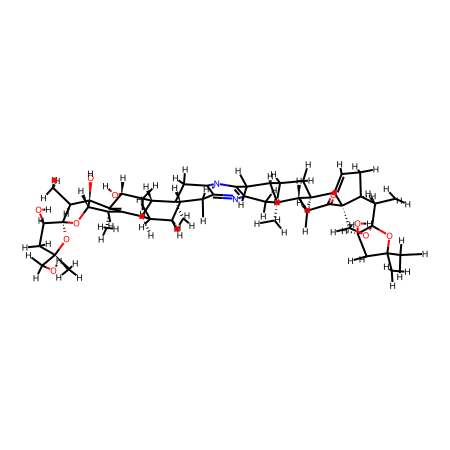

In [46]:
# Visualização 2D da molécula final
Draw.MolToImage(result["mol"], size=(450, 450))


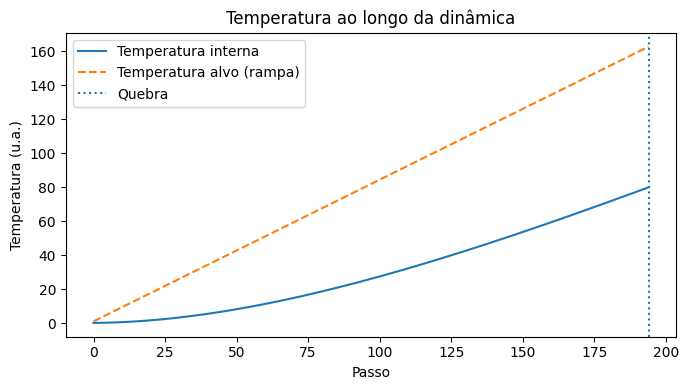

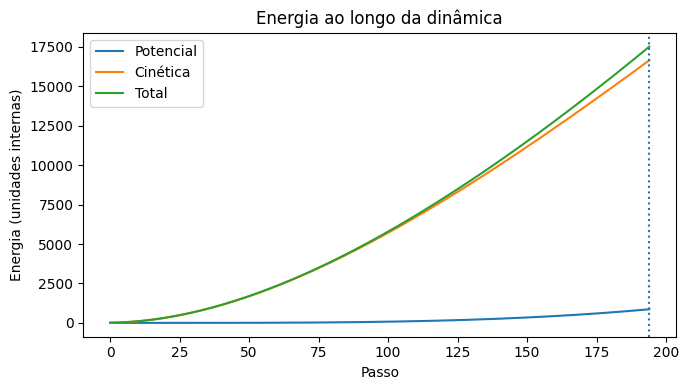

In [47]:
# =========================
# Gráficos da simulação
# =========================
steps = np.arange(len(result["temperatures"]))

plt.figure(figsize=(7, 4))
plt.plot(steps, result["temperatures"], label="Temperatura interna")
plt.plot(steps, result["target_temperatures"], "--", label="Temperatura alvo (rampa)")
if result["break_step"] is not None:
    plt.axvline(result["break_step"], linestyle=":", label="Quebra")
plt.xlabel("Passo")
plt.ylabel("Temperatura (u.a.)")
plt.title("Temperatura ao longo da dinâmica")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(steps, result["potential_energies"], label="Potencial")
plt.plot(steps, result["kinetic_energies"], label="Cinética")
plt.plot(steps, result["total_energies"], label="Total")
if result["break_step"] is not None:
    plt.axvline(result["break_step"], linestyle=":")
plt.xlabel("Passo")
plt.ylabel("Energia (unidades internas)")
plt.title("Energia ao longo da dinâmica")
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
# =========================
# Relatório das ligações no frame final
# =========================
final_pos = result["trajectory"][-1]
for bond_index, (i, j, r0, k) in enumerate(result["bonds"]):
    distance = np.linalg.norm(final_pos[i] - final_pos[j])
    threshold = break_factor * (result["radii"][i] + result["radii"][j])
    flag = "QUEBROU" if distance > threshold else "ok"
    print(
        f"{bond_index:02d} | {result['symbols'][i]}-{result['symbols'][j]} | "
        f"d0 = {r0:.2f} Å | d = {distance:.2f} Å | limite = {threshold:.2f} Å | {flag}"
    )


00 | C-C | d0 = 1.54 Å | d = 1.56 Å | limite = 2.28 Å | ok
01 | C-C | d0 = 1.53 Å | d = 1.45 Å | limite = 2.28 Å | ok
02 | C-O | d0 = 1.41 Å | d = 1.43 Å | limite = 2.13 Å | ok
03 | C-C | d0 = 1.54 Å | d = 1.49 Å | limite = 2.28 Å | ok
04 | C-C | d0 = 1.50 Å | d = 1.69 Å | limite = 2.28 Å | ok
05 | C-O | d0 = 1.41 Å | d = 1.29 Å | limite = 2.13 Å | ok
06 | C-C | d0 = 1.55 Å | d = 1.50 Å | limite = 2.28 Å | ok
07 | C-O | d0 = 1.44 Å | d = 1.49 Å | limite = 2.13 Å | ok
08 | C-C | d0 = 1.60 Å | d = 1.53 Å | limite = 2.28 Å | ok
09 | C-C | d0 = 1.54 Å | d = 1.41 Å | limite = 2.28 Å | ok
10 | C-C | d0 = 1.54 Å | d = 1.63 Å | limite = 2.28 Å | ok
11 | C-C | d0 = 1.53 Å | d = 1.65 Å | limite = 2.28 Å | ok
12 | C-C | d0 = 1.50 Å | d = 1.66 Å | limite = 2.28 Å | ok
13 | C-C | d0 = 1.35 Å | d = 1.36 Å | limite = 2.28 Å | ok
14 | C-C | d0 = 1.50 Å | d = 1.45 Å | limite = 2.28 Å | ok
15 | C-C | d0 = 1.56 Å | d = 1.64 Å | limite = 2.28 Å | ok
16 | C-C | d0 = 1.53 Å | d = 1.53 Å | limite = 2.28 Å | 

In [49]:
# =========================
# Animação da trajetória
# =========================
def animate_trajectory(result, interval=120, figsize=(6, 6)):
    frames = result["trajectory"]
    bonds = result["bonds"]
    symbols = result["symbols"]
    saved_steps = result["saved_steps"]

    coords_all = np.concatenate(frames, axis=0)
    xyz_min = coords_all.min(axis=0)
    xyz_max = coords_all.max(axis=0)
    center = 0.5 * (xyz_min + xyz_max)
    span = (xyz_max - xyz_min).max()
    pad = 0.25 * span + 0.5

    fig, ax = plt.subplots(figsize=figsize)

    def draw_frame(frame_index):
        ax.clear()
        pos = frames[frame_index]

        # desenha ligações que ainda estejam abaixo do limiar de quebra
        for i, j, r0, k in bonds:
            distance = np.linalg.norm(pos[i] - pos[j])
            threshold = break_factor * (result["radii"][i] + result["radii"][j])
            if distance <= threshold:
                ax.plot(
                    [pos[i, 0], pos[j, 0]],
                    [pos[i, 1], pos[j, 1]],
                    linewidth=2,
                )

        for idx, sym in enumerate(symbols):
            ax.scatter(
                pos[idx, 0], pos[idx, 1],
                s=ATOM_SIZE_MAP.get(sym, 140),
                c=ATOM_COLOR_MAP.get(sym, "gray"),
                edgecolors="white",
                linewidths=0.8,
                zorder=3
            )
            ax.text(pos[idx, 0], pos[idx, 1], sym, ha="center", va="center", fontsize=8, zorder=4)

        ax.set_aspect("equal")
        ax.set_xlim(center[0] - span / 2 - pad, center[0] + span / 2 + pad)
        ax.set_ylim(center[1] - span / 2 - pad, center[1] + span / 2 + pad)

        step = int(saved_steps[frame_index])
        title = f"Frame {frame_index + 1}/{len(frames)} | passo {step}"
        if step > 0:
            idx = min(step - 1, len(result["target_temperatures"]) - 1)
            title += f" | T alvo ≈ {result['target_temperatures'][idx]:.1f} K"
        if result["break_step"] is not None and step >= result["break_step"]:
            title += " | QUEBRA"
        ax.set_title(title)
        ax.set_xlabel("x (Å)")
        ax.set_ylabel("y (Å)")
        ax.grid(alpha=0.2)

    anim = FuncAnimation(fig, draw_frame, frames=len(frames), interval=interval, repeat=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

display(animate_trajectory(result))
